<a href="https://colab.research.google.com/github/amandachipolito/Trabalho-BCI/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Instalar Bibliotecas

In [1]:
!python3 -m pip install --upgrade pip
!pip download numpy pathlib scipy gdown matplotlib scikit-learn
!pip install numpy pathlib scipy gdown matplotlib scikit-learn


  File was already downloaded /workspaces/Trabalho-BCI/numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
  File was already downloaded /workspaces/Trabalho-BCI/pathlib-1.0.1-py3-none-any.whl
  File was already downloaded /workspaces/Trabalho-BCI/scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
  File was already downloaded /workspaces/Trabalho-BCI/gdown-6.0.0-py3-none-any.whl
  File was already downloaded /workspaces/Trabalho-BCI/matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl
  File was already downloaded /workspaces/Trabalho-BCI/scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
  File was already downloaded /workspaces/Trabalho-BCI/beautifulsoup4-4.14.3-py3-none-any.whl
  File was already downloaded /workspaces/Trabalho-BCI/filelock-3.29.0-py3-none-any.whl
  File was already downloaded /workspaces/Trabalho-BCI/requests-2.33.1-py3-none-any.whl
  File was already downloaded /workspac

# 2 - Importar Bibliotecas

In [2]:
import glob
import os
import sys
import numpy as np
from pathlib import Path
from scipy.io import loadmat


# 3 - Definir pasta local e link do Google Drive

In [3]:
IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("/content/Projeto_BCI" if IN_COLAB else "./Projeto_BCI").resolve()

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1l2wfRKe3_xGU0otL7aIvcwXn578fGs7a?usp=sharing"

print("Pasta dos dados:", DATA_DIR)

Pasta dos dados: /workspaces/Trabalho-BCI/Projeto_BCI


# 4 - Baixar arquivos .mat

In [4]:
if not DATA_DIR.exists():
    import gdown

    print(f"Baixando arquivos para: {DATA_DIR}")
    gdown.download_folder(
        GDRIVE_FOLDER_URL,
        output=str(DATA_DIR),
        quiet=False,
        use_cookies=False
    )
else:
    print("A pasta já existe. Download não realizado novamente.")

A pasta já existe. Download não realizado novamente.


# 5 - Listar arquivos encontrados

In [5]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"{len(files)} arquivos .mat encontrados:")

for file in files:
    print(os.path.basename(file))

8 arquivos .mat encontrados:
covertShiftsOfAttention_VPgao.mat
covertShiftsOfAttention_VPiaa.mat
covertShiftsOfAttention_VPiac.mat
covertShiftsOfAttention_VPiae.mat
covertShiftsOfAttention_VPiah.mat
covertShiftsOfAttention_VPiai.mat
covertShiftsOfAttention_VPmk.mat
covertShiftsOfAttention_VPnh.mat


# 6 - Carregar os dados corretamente

In [6]:
data_list = []
fs_list = []
nomes_arquivos = []

for fname in files:
    nome = os.path.basename(fname)

    mat = loadmat(fname, squeeze_me=True, struct_as_record=False)

    data = mat["data"]

    X = np.asarray(data.X, dtype=float)
    fs = int(data.fs)

    data_list.append(X)
    fs_list.append(fs)
    nomes_arquivos.append(nome)

    print(f"{nome}")
    print(f"  X shape: {X.shape}")
    print(f"  fs: {fs} Hz")
    print()

covertShiftsOfAttention_VPgao.mat
  X shape: (579736, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiaa.mat
  X shape: (581804, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiac.mat
  X shape: (657660, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiae.mat
  X shape: (613408, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiah.mat
  X shape: (604788, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiai.mat
  X shape: (429348, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPmk.mat
  X shape: (592640, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPnh.mat
  X shape: (596576, 62)
  fs: 200 Hz



# 7 - Conferir se todos tem a mesma frequência de amostragem

In [7]:
frequencias = sorted(set(fs_list))

print("Frequências encontradas:", frequencias)

if len(frequencias) == 1:
    fs = frequencias[0]
    print(f"Todos os arquivos têm fs = {fs} Hz")
else:
    print("Atenção: existem frequências diferentes entre os arquivos.")

Frequências encontradas: [200]
Todos os arquivos têm fs = 200 Hz


# 8 - Conferir o formato dos dados

In [8]:
X_exemplo = data_list[0]

print("Shape do primeiro arquivo:", X_exemplo.shape)

n_amostras = X_exemplo.shape[0]
n_canais = X_exemplo.shape[1]

print("Número de amostras:", n_amostras)
print("Número de canais:", n_canais)

Shape do primeiro arquivo: (579736, 62)
Número de amostras: 579736
Número de canais: 62


# 9 - Criar a função de filtragem

In [9]:
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt

def aplicar_filtros_eeg(X, fs):
    X = np.asarray(X, dtype=float)

    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    X_notch = filtfilt(b_notch, a_notch, X, axis=0)

    sos = butter(
        4,
        [5.0, 40.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filtrado = sosfiltfilt(sos, X_notch, axis=0)

    return X_filtrado

# 10 - Filtrar todos os participantes

In [10]:
data_filtrada = []

for X, fs, nome in zip(data_list, fs_list, nomes_arquivos):
    print(f"Filtrando {nome}...")

    X_filtrado = aplicar_filtros_eeg(X, fs)

    data_filtrada.append(X_filtrado)

    print(f"  Antes: {X.shape}")
    print(f"  Depois: {X_filtrado.shape}")
    print()

Filtrando covertShiftsOfAttention_VPgao.mat...
  Antes: (579736, 62)
  Depois: (579736, 62)

Filtrando covertShiftsOfAttention_VPiaa.mat...
  Antes: (581804, 62)
  Depois: (581804, 62)

Filtrando covertShiftsOfAttention_VPiac.mat...
  Antes: (657660, 62)
  Depois: (657660, 62)

Filtrando covertShiftsOfAttention_VPiae.mat...
  Antes: (613408, 62)
  Depois: (613408, 62)

Filtrando covertShiftsOfAttention_VPiah.mat...
  Antes: (604788, 62)
  Depois: (604788, 62)

Filtrando covertShiftsOfAttention_VPiai.mat...
  Antes: (429348, 62)
  Depois: (429348, 62)

Filtrando covertShiftsOfAttention_VPmk.mat...
  Antes: (592640, 62)
  Depois: (592640, 62)

Filtrando covertShiftsOfAttention_VPnh.mat...
  Antes: (596576, 62)
  Depois: (596576, 62)



# 11 - Verificar resultado final

In [11]:
print("Total de arquivos originais:", len(data_list))
print("Total de arquivos filtrados:", len(data_filtrada))

print("\nExemplo do primeiro participante:")
print("Original:", data_list[0].shape)
print("Filtrado:", data_filtrada[0].shape)

Total de arquivos originais: 8
Total de arquivos filtrados: 8

Exemplo do primeiro participante:
Original: (579736, 62)
Filtrado: (579736, 62)


# 12 - Plotar alguns canais do EEG

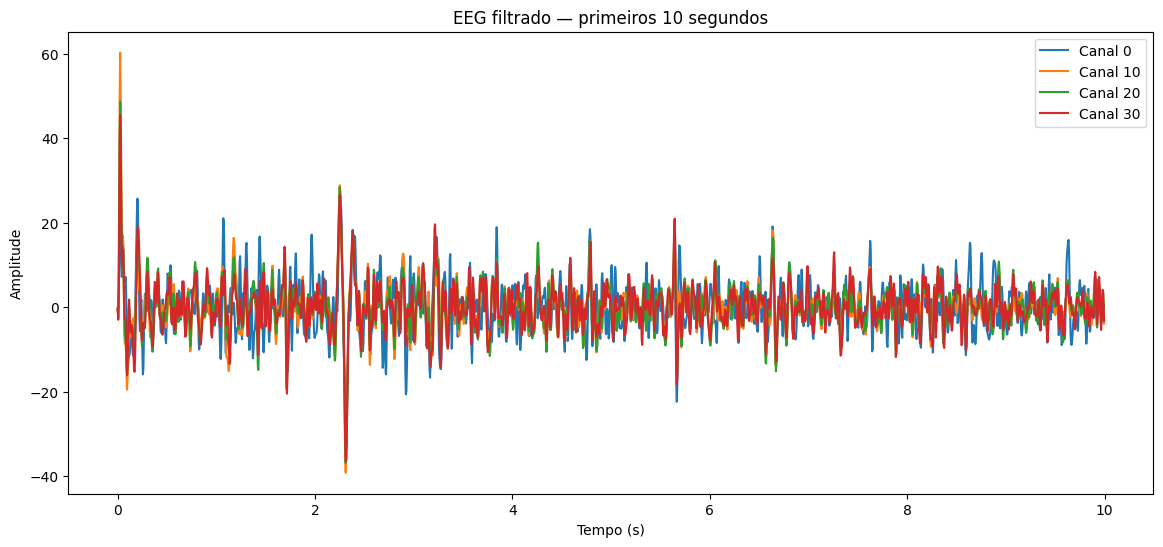

In [12]:
import matplotlib.pyplot as plt

idx_participante = 0
X = data_filtrada[idx_participante]

fs = fs_list[idx_participante]

tempo = np.arange(X.shape[0]) / fs

canais_para_plotar = [0, 10, 20, 30]

plt.figure(figsize=(14,6))

for canal in canais_para_plotar:
    plt.plot(
        tempo[:2000],
        X[:2000, canal],
        label=f"Canal {canal}"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG filtrado — primeiros 10 segundos")
plt.legend()
plt.show()

# 13 - Inspecionar estrutura dos trials

In [13]:
idx = 0

mat = loadmat(
    files[idx],
    squeeze_me=True,
    struct_as_record=False
)

data = mat["data"]
mrk = mat["mrk"]

trial = data.trial
labels = data.y

print("Número de trials:", len(trial))

print("\nPrimeiros trials:")
print(trial[:10])

print("\nPrimeiros labels:")
print(labels[:10])

Número de trials: 600

Primeiros trials:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros labels:
[2 1 3 1 2 4 3 6 3 3]


# 14 - Calcular duração dos trials

In [14]:
trial_diff = np.diff(trial)

print("Primeiros tamanhos de trials:")
print(trial_diff[:10])

print("\nMédia:")
print(int(np.mean(trial_diff)))

print("\nMínimo:")
print(np.min(trial_diff))

print("\nMáximo:")
print(np.max(trial_diff))

Primeiros tamanhos de trials:
[1062  825 1063 1062  904  884 1062 1062  859 1062]

Média:
964

Mínimo:
762

Máximo:
1903


# 15 - Inspecionar estrutura dos eventos cue/target

In [15]:
print("Campos dentro de mrk.target_location:")

if hasattr(mrk.target_location, "_fieldnames"):
    print(mrk.target_location._fieldnames)
else:
    print("Não é struct")

Campos dentro de mrk.target_location:
['pos', 'toe', 'fs', 'y', 'className']


## 15.1 - Inspecionar conteúdo dos campos de target_location

In [16]:
for campo in mrk.target_location._fieldnames:
    valor = getattr(mrk.target_location, campo)

    print("\nCampo:", campo)
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)

    if hasattr(valor, "__len__"):
        try:
            print("Primeiros valores:")
            print(valor[:20])
        except:
            pass


Campo: pos
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190 11252 12015
 13081 14127 15194 16135 17194 18256 19319 20381]

Campo: toe
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[37 30 32 30 37 39 30 41 37 32 32 34 39 37 34 37 32 41 34 41]

Campo: fs
Tipo: <class 'int'>

Campo: y
Tipo: <class 'numpy.ndarray'>
Shape: (6, 600)
Primeiros valores:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Campo: className
Tipo: <class 'numpy.ndarray'>
Shape: (6,)
Primeiros valores:
['target @1' 'target @2' 'target @3' 'target @4' 'target @5' 'target @6']


# 16 - Calcular delay entre cue e target

In [17]:
cue_pos = data.trial
target_pos = mrk.target_location.pos

print("Primeiros cue_pos:")
print(cue_pos[:10])

print("\nPrimeiros target_pos:")
print(target_pos[:10])

delay = target_pos - cue_pos

print("\nDelay entre cue e target em amostras:")
print(delay[:20])

print("\nDelay médio em segundos:")
print(np.mean(delay) / fs)

print("\nDelay mínimo em segundos:")
print(np.min(delay) / fs)

print("\nDelay máximo em segundos:")
print(np.max(delay) / fs)

Primeiros cue_pos:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros target_pos:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190]

Delay entre cue e target em amostras:
[429 192 430 429 271 250 429 429 225 429 429 129 429 412 433 308 425 429
 430 429]

Delay médio em segundos:
1.621925

Delay mínimo em segundos:
0.645

Delay máximo em segundos:
2.17


# 17 - Criar epochs alinhadas ao cue

Nesta etapa segmentamos o sinal EEG filtrado usando os instantes de cue
como referência temporal.

Cada epoch será extraída do intervalo entre:

cue → target

Esse intervalo representa o período em que o participante recebeu o cue
e manteve a atenção encoberta até o surgimento do target.

Cada epoch será armazenada como uma matriz:

[n_amostras × n_canais]

In [18]:
idx_participante = 0

X = data_filtrada[idx_participante]

cue_pos = data.trial
target_pos = mrk.target_location.pos
target_y = mrk.target_location.y

epochs_cue_target = []
labels_cue_target = []

for i in range(len(cue_pos)):

    inicio = cue_pos[i]
    fim = target_pos[i]

    if fim > inicio and fim <= X.shape[0]:

        epoch = X[inicio:fim, :]

        classe = np.argmax(target_y[:, i])

        epochs_cue_target.append(epoch)
        labels_cue_target.append(classe)

labels_cue_target = np.array(labels_cue_target)

print("Número de epochs criadas:", len(epochs_cue_target))
print("Número de labels:", len(labels_cue_target))

print("\nPrimeiras shapes das epochs:")

for i in range(5):
    print(f"Epoch {i}:", epochs_cue_target[i].shape)

print("\nPrimeiros labels:")
print(labels_cue_target[:10])

Número de epochs criadas: 600
Número de labels: 600

Primeiras shapes das epochs:
Epoch 0: (429, 62)
Epoch 1: (192, 62)
Epoch 2: (430, 62)
Epoch 3: (429, 62)
Epoch 4: (271, 62)

Primeiros labels:
[1 0 2 0 1 3 0 5 1 2]


# 18 - Padronizar tamanho das epochs usando delay mínimo

Como os intervalos cue→target variam entre trials,
definimos o tamanho da janela fixa com base no menor delay encontrado.

Isso garante que todas as epochs tenham o mesmo tamanho
sem remover trials.

A janela final será:

cue → cue + delay_mínimo

In [19]:
delay = target_pos - cue_pos

janela_amostras = int(np.min(delay))

print("Janela escolhida (amostras):", janela_amostras)
print("Janela escolhida (segundos):", janela_amostras / fs)

epochs_padronizadas = []
labels_padronizadas = []

for epoch, label in zip(epochs_cue_target, labels_cue_target):

    epoch_fixada = epoch[:janela_amostras, :]

    epochs_padronizadas.append(epoch_fixada)
    labels_padronizadas.append(label)

epochs_padronizadas = np.array(epochs_padronizadas)
labels_padronizadas = np.array(labels_padronizadas)

print("\nShape final das epochs:")
print(epochs_padronizadas.shape)

print("\nShape final dos labels:")
print(labels_padronizadas.shape)

print("\nTotal de trials mantidos:", len(epochs_padronizadas))

Janela escolhida (amostras): 129
Janela escolhida (segundos): 0.645

Shape final das epochs:
(600, 129, 62)

Shape final dos labels:
(600,)

Total de trials mantidos: 600


# 19 - Converter epochs para matriz 2D

Nesta etapa convertemos as epochs tridimensionais:

[n_trials × n_amostras × n_canais]

em uma matriz bidimensional:

[n_trials × n_features]

Cada epoch será transformada em um vetor único,
permitindo o uso de métodos como PCA e classificadores.

In [20]:
n_trials = epochs_padronizadas.shape[0]
n_amostras = epochs_padronizadas.shape[1]
n_canais = epochs_padronizadas.shape[2]

X_features = epochs_padronizadas.reshape(
    n_trials,
    n_amostras * n_canais
)

print("Shape original:")
print(epochs_padronizadas.shape)

print("\nShape após flatten:")
print(X_features.shape)

print("\nNúmero total de features por trial:")
print(n_amostras * n_canais)

Shape original:
(600, 129, 62)

Shape após flatten:
(600, 7998)

Número total de features por trial:
7998


# 20 - Padronizar os dados (z-score)

Nesta etapa padronizamos cada feature para ter:

média = 0  
desvio padrão = 1  

Essa transformação é necessária antes da aplicação do PCA,
pois garante que todas as features contribuam de forma equilibrada
para o cálculo da matriz de covariância.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X_features)

print("Shape após padronização:")
print(X_padronizado.shape)

print("\nMédia aproximada (primeiras features):")
print(np.mean(X_padronizado[:, :5], axis=0))

print("\nDesvio padrão aproximado (primeiras features):")
print(np.std(X_padronizado[:, :5], axis=0))

Shape após padronização:
(600, 7998)

Média aproximada (primeiras features):
[ 4.92198874e-17 -5.77315973e-17 -1.56356409e-17  1.99840144e-17
 -9.69594775e-17]

Desvio padrão aproximado (primeiras features):
[1. 1. 1. 1. 1.]


# 21 - Aplicar PCA (Análise inicial)

Nesta etapa aplicamos PCA aos dados padronizados
para identificar as principais direções de variância
presentes nos sinais EEG.

Inicialmente, calculamos todos os componentes
para avaliar:

- variância explicada por cada componente
- variância acumulada
- número ideal de componentes principais

In [22]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_padronizado)

variancia_explicada = pca.explained_variance_ratio_

variancia_acumulada = np.cumsum(variancia_explicada)

print("Shape após PCA:")
print(X_pca.shape)

print("\nPrimeiras variâncias explicadas:")
print(variancia_explicada[:10])

print("\nVariância acumulada:")
print(variancia_acumulada[:10])

Shape após PCA:
(600, 600)

Primeiras variâncias explicadas:
[0.04187193 0.03719564 0.03393339 0.03069966 0.02886833 0.0287934
 0.02567112 0.02265234 0.02153865 0.01853651]

Variância acumulada:
[0.04187193 0.07906757 0.11300096 0.14370062 0.17256895 0.20136236
 0.22703348 0.24968582 0.27122446 0.28976098]


# 22 - Analisar variância explicada pelo PCA

Nesta etapa geramos gráficos para visualizar:

- variância explicada por cada componente (Scree Plot)
- variância acumulada

Esses gráficos permitem determinar quantos componentes
principais devem ser mantidos na redução de dimensionalidade.

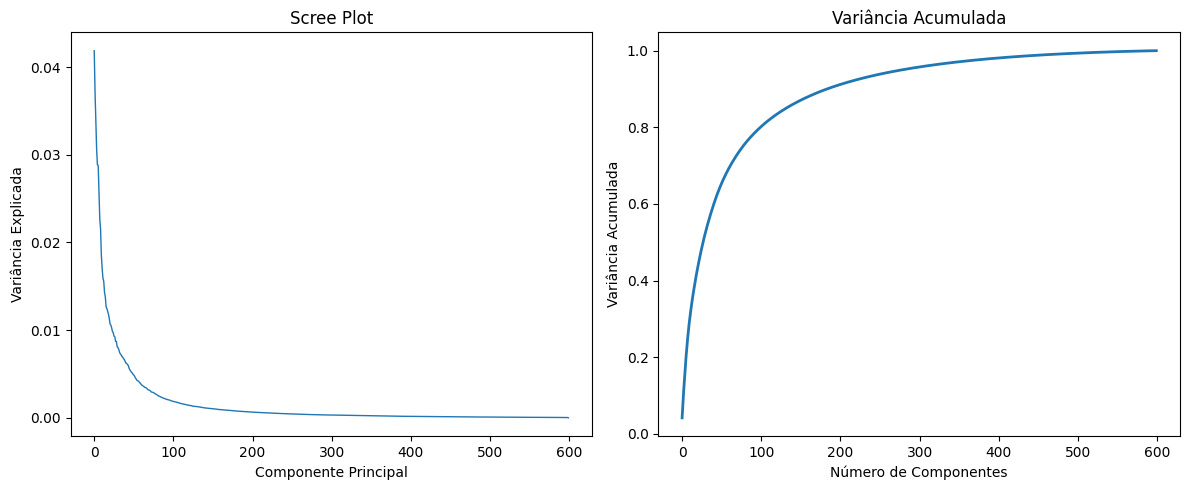

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(variancia_explicada, linewidth=1)

plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("Scree Plot")

plt.subplot(1,2,2)

plt.plot(variancia_acumulada, linewidth=2)

plt.xlabel("Número de Componentes")
plt.ylabel("Variância Acumulada")
plt.title("Variância Acumulada")

plt.tight_layout()

plt.show()

# 23 - PCA com redução dimensional

Nesta etapa aplicamos PCA mantendo apenas o número necessário
de componentes para explicar aproximadamente 90% da variância total.

Essa redução diminui significativamente o número de features,
preservando a maior parte da informação relevante dos sinais EEG.

## 23.1 - Seleção do número de componentes

## 23.2 - Aplicação do PCA reduzido

In [24]:
n_componentes = np.argmax(variancia_acumulada >= 0.90) + 1

print("Número de componentes para 90% da variância:")
print(n_componentes)

pca_reduzido = PCA(n_components=n_componentes)

X_pca_reduzido = pca_reduzido.fit_transform(X_padronizado)

print("\nShape após redução:")
print(X_pca_reduzido.shape)

Número de componentes para 90% da variância:
184

Shape após redução:
(600, 184)


# 25 - Verificação pós-PCA (pré-ICA)

Antes de aplicar a Análise de Componentes Independentes (ICA), é necessário verificar se os dados após a redução dimensional pelo PCA estão adequados para a etapa seguinte.

Nesta etapa verificamos:

- o formato da matriz reduzida
- a variância preservada após a redução
- se o número de dimensões é menor que o número de observações
- a média e variância dos componentes após PCA

Essas verificações garantem estabilidade numérica e evitam falhas durante a aplicação do ICA.

In [25]:
print("=== Verificação pós-PCA ===")

# 1 — Shape dos dados reduzidos

print("\nShape após PCA reduzido:")
print(X_pca_reduzido.shape)

n_amostras, n_features = X_pca_reduzido.shape

# 2 — Verificar condição necessária para ICA

print("\nVerificando condição para ICA:")

if n_features < n_amostras:
    print("OK — Número de componentes menor que número de amostras")
else:
    print("ATENÇÃO — Pode haver problema no ICA")

# 3 — Variância preservada

variancia_total_preservada = variancia_acumulada[n_componentes - 1]

print("\nVariância total preservada:")
print(variancia_total_preservada)

# 4 — Média das primeiras componentes

media_componentes = np.mean(X_pca_reduzido[:, :5], axis=0)

print("\nMédia das primeiras componentes:")
print(media_componentes)

# 5 — Variância das primeiras componentes

variancia_componentes = np.var(X_pca_reduzido[:, :5], axis=0)

print("\nVariância das primeiras componentes:")
print(variancia_componentes)

print("\n=== Verificação concluída ===")

=== Verificação pós-PCA ===

Shape após PCA reduzido:
(600, 184)

Verificando condição para ICA:
OK — Número de componentes menor que número de amostras

Variância total preservada:
0.900137585440021

Média das primeiras componentes:
[-2.94579176e-16  3.55271368e-17  4.10875038e-16  9.76996262e-16
  1.77635684e-17]

Variância das primeiras componentes:
[334.89170933 297.49070847 271.39925564 245.53587692 230.88893643]

=== Verificação concluída ===
